In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette("bright")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = pd.read_csv('../data/climate_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"📊 Dataset Shape: {df.shape}")
print(f"📅 Date Range: {df['Date'].min()} to {df['Date'].max()}")
df.head(10)

📊 Dataset Shape: (1825, 9)
📅 Date Range: 2019-01-01 00:00:00 to 2023-12-30 00:00:00


,Date,Temperature,Humidity,Pressure,Wind_Speed,Rainfall,CO2_Level,Visibility,Cloud_Cover
0,2019-01-01,16.71,58.96,1016.24,27.18,0.08,410.28,9.02,35.48
1,2019-01-02,13.68,54.97,1008.38,0.00,0.17,410.95,4.97,57.86
2,2019-01-03,12.58,46.91,1020.33,13.19,0.11,412.56,7.79,53.06
3,2019-01-04,13.80,55.37,1017.74,17.33,0.29,409.36,6.97,23.56
4,2019-01-05,17.86,49.51,1014.04,0.00,0.40,410.22,8.76,24.77
5,2019-01-06,10.69,69.80,1010.31,4.23,0.39,409.12,7.65,40.37
6,2019-01-07,13.46,68.52,1018.15,22.45,0.74,409.79,5.75,12.30
7,2019-01-08,18.84,60.97,1010.95,24.44,0.51,409.10,6.86,75.09
8,2019-01-09,16.69,56.63,1014.81,27.30,0.74,413.37,5.16,40.03
9,2019-01-10,15.48,49.24,1018.21,22.23,0.14,410.02,9.96,37.04


In [3]:
print("=" * 60)
print("📋 DATASET INFORMATION")
print("=" * 60)
print(f"\n🔢 Total Records: {len(df)}")
print(f"📊 Total Features: {len(df.columns)}")
print(f"\n📌 Column Types:")
print(df.dtypes)
print(f"\n❌ Missing Values:")
print(df.isnull().sum())
print(f"\n📈 Statistics:")
df.describe().round(2)

📋 DATASET INFORMATION

🔢 Total Records: 1825
📊 Total Features: 9

📌 Column Types:
Date           datetime64[us]
Temperature           float64
Humidity              float64
Pressure              float64
Wind_Speed            float64
Rainfall              float64
CO2_Level             float64
Visibility            float64
Cloud_Cover           float64
dtype: object

❌ Missing Values:
Date           0
Temperature    0
Humidity       0
Pressure       0
Wind_Speed     0
Rainfall       0
CO2_Level      0
Visibility     0
Cloud_Cover    0
dtype: int64

📈 Statistics:


,Date,Temperature,Humidity,Pressure,Wind_Speed,Rainfall,CO2_Level,Visibility,Cloud_Cover
count,1825,1825.00,1825.00,1825.00,1825.00,1825.00,1825.00,1825.00,1825.00
mean,2021-07-01 00:00:00,25.57,60.03,1012.86,15.08,1.00,414.99,6.99,49.64
min,2019-01-01 00:00:00,5.55,20.00,995.09,0.00,0.00,407.44,1.00,0.00
25%,2020-04-01 00:00:00,18.82,46.35,1009.56,9.70,0.20,411.94,5.74,33.16
50%,2021-07-01 00:00:00,25.40,60.44,1012.74,15.03,0.51,414.89,7.09,49.00
75%,2022-09-30 00:00:00,32.20,73.51,1016.25,20.31,1.19,418.12,8.42,67.03
max,2023-12-30 00:00:00,43.83,100.00,1029.43,40.10,13.29,422.80,10.00,100.00
std,NaN,7.80,17.21,5.06,7.78,1.41,3.66,1.91,23.85


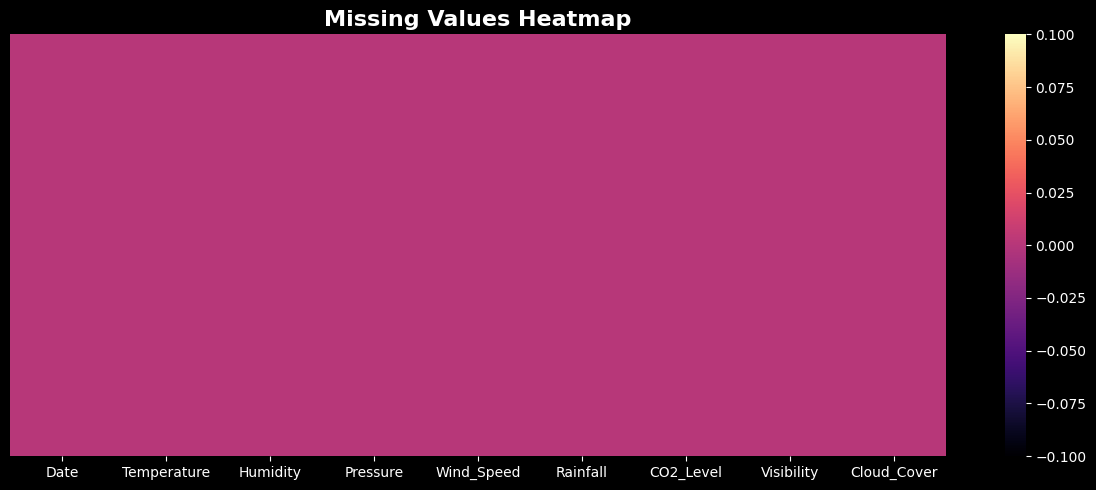

✅ No missing values!


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='magma')
plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ No missing values!" if df.isnull().sum().sum() == 0 
      else "⚠️ Missing values found!")

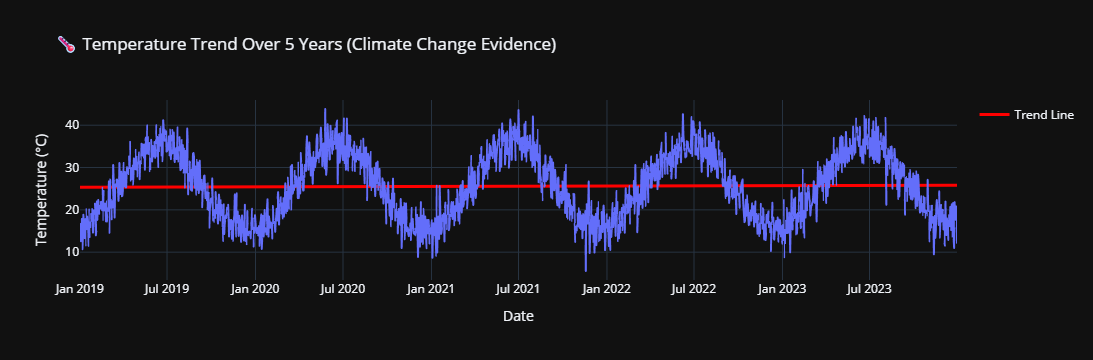

📈 Temperature increasing at 0.10°C per year


In [5]:
fig = px.line(df, x='Date', y='Temperature',
              title='🌡️ Temperature Trend Over 5 Years (Climate Change Evidence)',
              labels={'Temperature': 'Temperature (°C)'})

# Add trend line
z = np.polyfit(range(len(df)), df['Temperature'], 1)
p = np.poly1d(z)
fig.add_trace(go.Scatter(x=df['Date'], y=p(range(len(df))),
                          mode='lines', name='Trend Line',
                          line=dict(color='red', width=3)))
fig.update_layout(template='plotly_dark')
fig.show()

print(f"📈 Temperature increasing at {z[0]*365:.2f}°C per year")

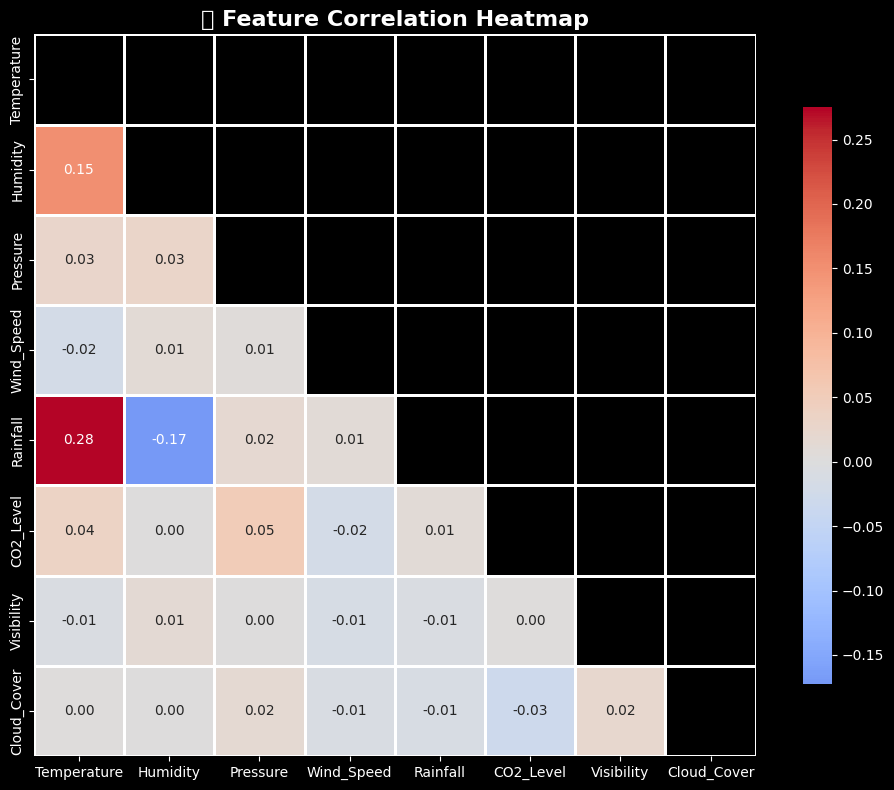

In [6]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('🔗 Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

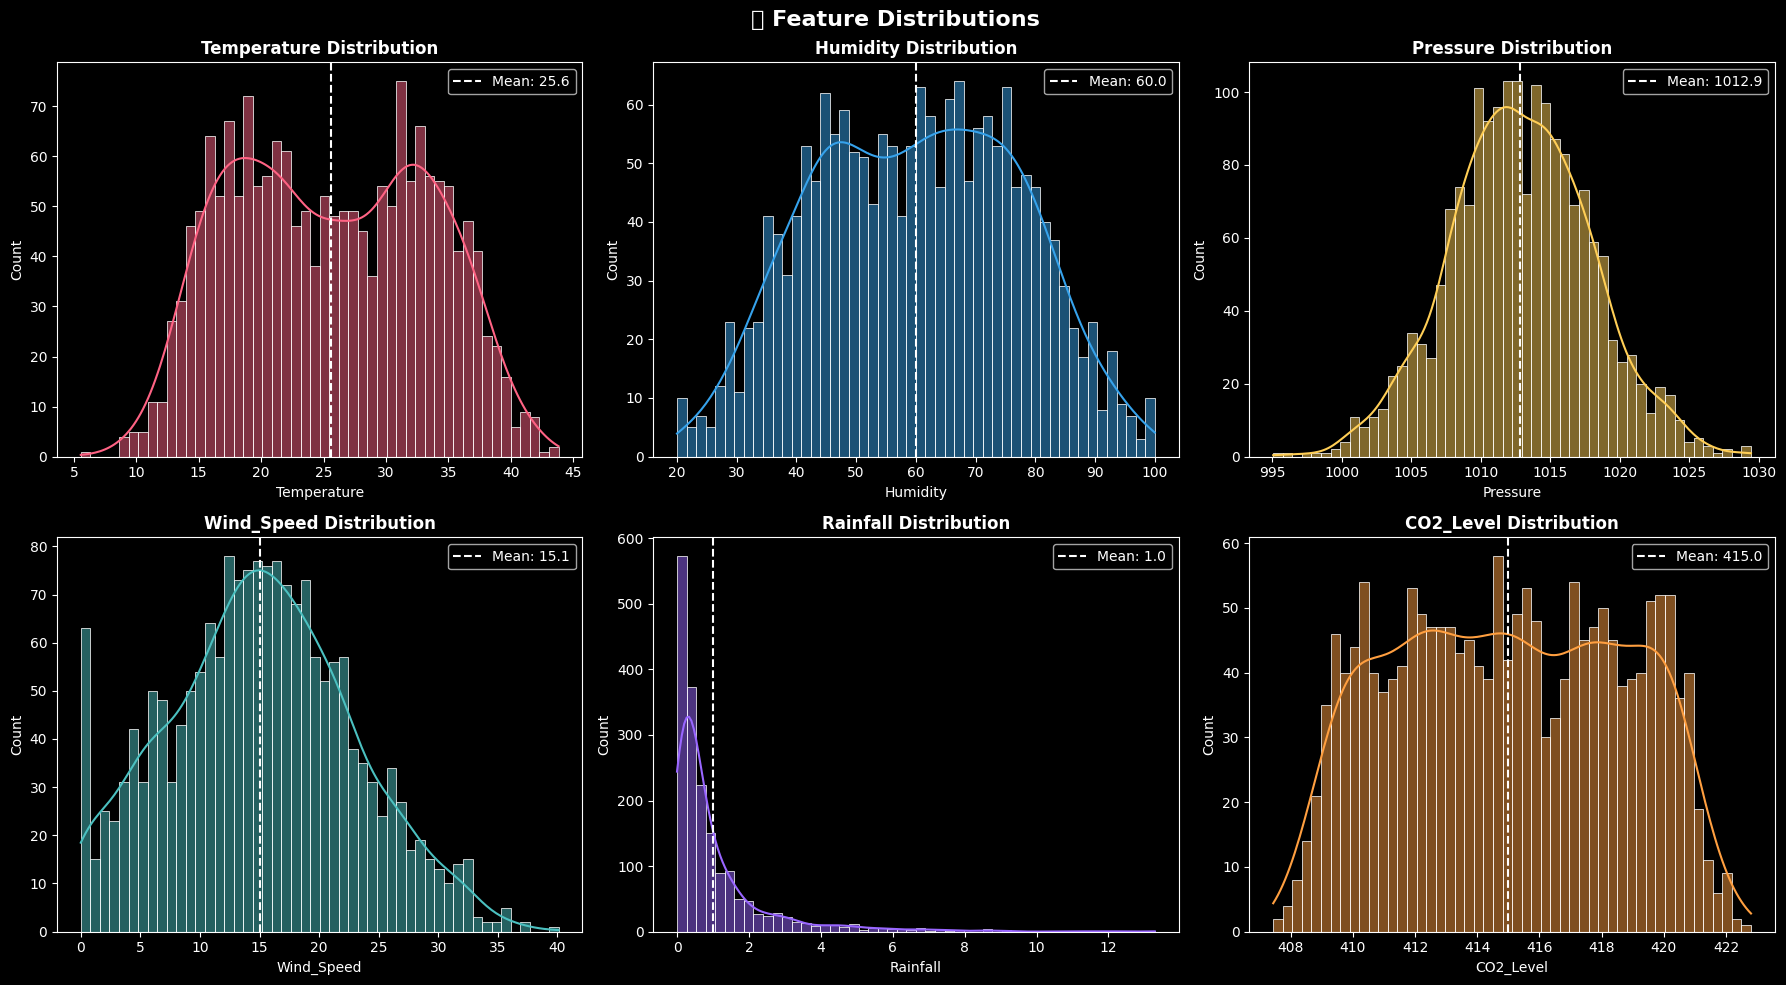

In [7]:
features = ['Temperature', 'Humidity', 'Pressure', 
            'Wind_Speed', 'Rainfall', 'CO2_Level']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#FF6384', '#36A2EB', '#FFCE56', '#4BC0C0', '#9966FF', '#FF9F40']

for i, (feature, color) in enumerate(zip(features, colors)):
    row, col = i // 3, i % 3
    sns.histplot(df[feature], kde=True, ax=axes[row][col], color=color, bins=50)
    axes[row][col].set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    axes[row][col].axvline(df[feature].mean(), color='white', linestyle='--', label=f'Mean: {df[feature].mean():.1f}')
    axes[row][col].legend()

plt.suptitle('📊 Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

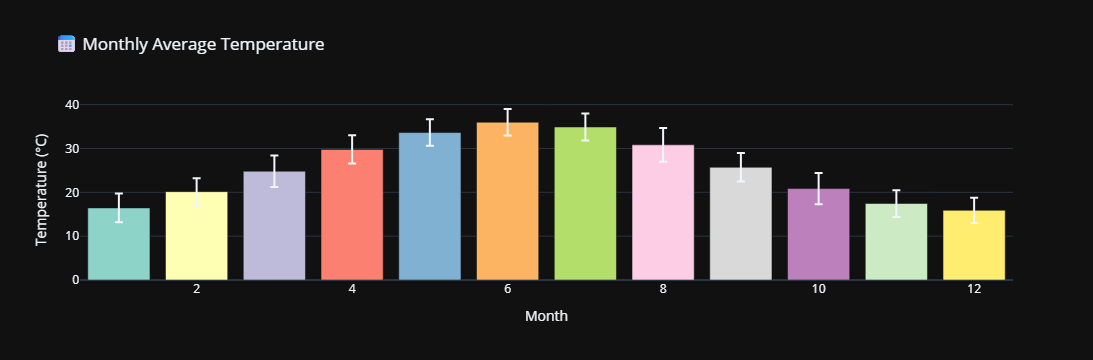

In [8]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')

monthly = df.groupby('Month')['Temperature'].agg(['mean', 'std']).reset_index()

fig = go.Figure()
fig.add_trace(go.Bar(x=monthly['Month'], y=monthly['mean'],
                      error_y=dict(type='data', array=monthly['std']),
                      marker_color=px.colors.qualitative.Set3))
fig.update_layout(title='📅 Monthly Average Temperature',
                  xaxis_title='Month', yaxis_title='Temperature (°C)',
                  template='plotly_dark')
fig.show()

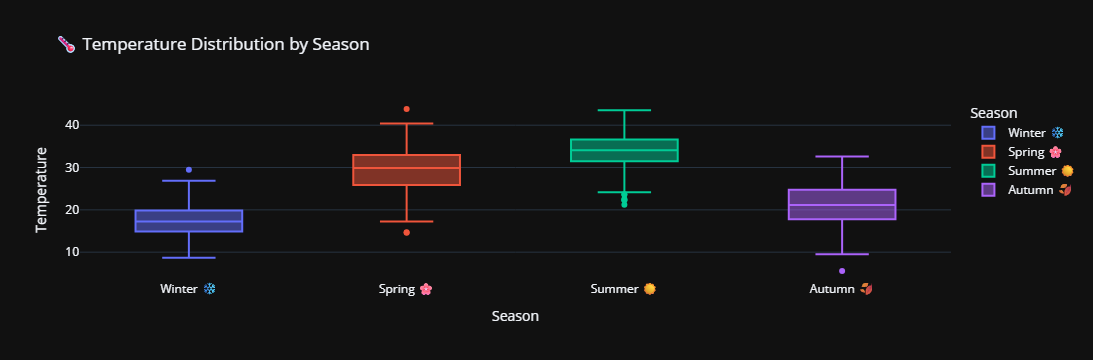

In [9]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter ❄️'
    elif month in [3, 4, 5]: return 'Spring 🌸'
    elif month in [6, 7, 8]: return 'Summer ☀️'
    else: return 'Autumn 🍂'

df['Season'] = df['Month'].apply(get_season)

fig = px.box(df, x='Season', y='Temperature', color='Season',
             title='🌡️ Temperature Distribution by Season')
fig.update_layout(template='plotly_dark')
fig.show()


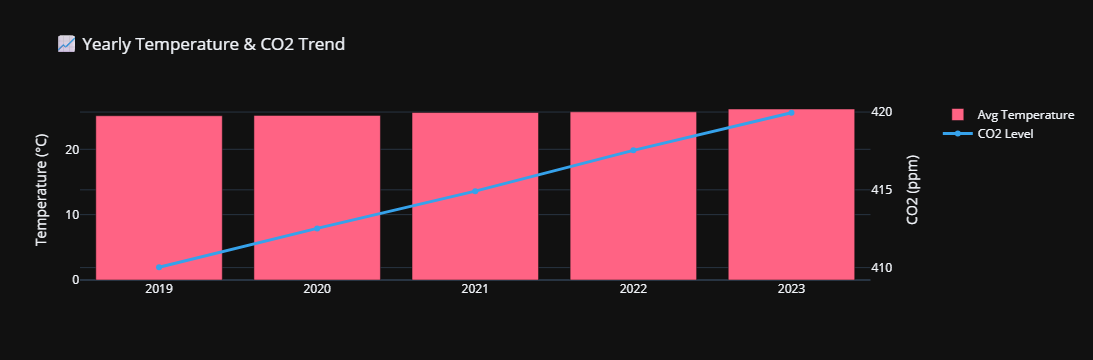

In [12]:
yearly = df.groupby('Year')[['Temperature', 'CO2_Level']].mean().reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=yearly['Year'], y=yearly['Temperature'],
                      name='Avg Temperature', marker_color='#FF6384'),
              secondary_y=False)
fig.add_trace(go.Scatter(x=yearly['Year'], y=yearly['CO2_Level'],
                          name='CO2 Level', line=dict(color='#36A2EB', width=3)),
              secondary_y=True)
fig.update_layout(title='📈 Yearly Temperature & CO2 Trend',
                  template='plotly_dark')
fig.update_yaxes(title_text="Temperature (°C)", secondary_y=False)
fig.update_yaxes(title_text="CO2 (ppm)", secondary_y=True)
fig.show()

In [13]:
print("=" * 60)
print("🔍 KEY EDA FINDINGS")
print("=" * 60)
print(f"""
1. 🌡️ Temperature Range: {df['Temperature'].min():.1f}°C to {df['Temperature'].max():.1f}°C
2. 📈 Warming Trend: ~{z[0]*365:.2f}°C per year
3. 🏭 CO2 Correlation with Temp: {corr.loc['Temperature','CO2_Level']:.3f}
4. 💧 Humidity Correlation: {corr.loc['Temperature','Humidity']:.3f}
5. 🌧️ Max Rainfall: {df['Rainfall'].max():.1f}mm
6. 📊 Most correlated feature: {corr['Temperature'].drop('Temperature').abs().idxmax()}
""")




🔍 KEY EDA FINDINGS

1. 🌡️ Temperature Range: 5.5°C to 43.8°C
2. 📈 Warming Trend: ~0.10°C per year
3. 🏭 CO2 Correlation with Temp: 0.037
4. 💧 Humidity Correlation: 0.151
5. 🌧️ Max Rainfall: 13.3mm
6. 📊 Most correlated feature: Rainfall

